<a href="https://colab.research.google.com/github/SonaliNidhi/Financial-Risk-Intelligence-System./blob/main/Financial_Risk_Intelligence_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Install Dependencies

!pip install xgboost lightgbm imbalanced-learn shap networkx

In [ ]:
# Import Library

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.metrics import average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

import shap
import pickle
import networkx as nx
import random

In [ ]:
# Load Dataset

df = pd.read_csv("paysim.csv")

print(df.shape)
df.head()

(2008108, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2008108 entries, 0 to 2008107
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 168.5+ MB


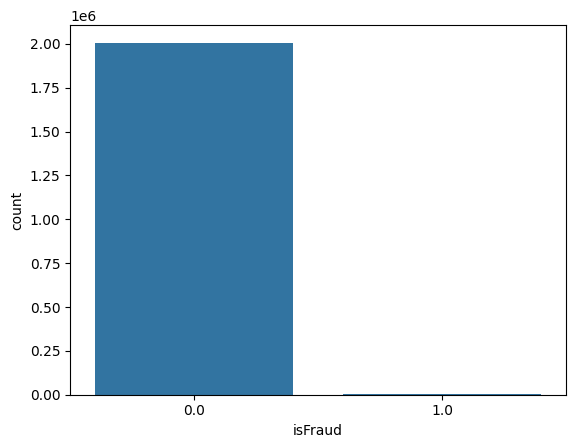

In [ ]:
# Basic EDA

df.info()
df.describe()

sns.countplot(x='isFraud', data=df)
plt.show()

In [ ]:
# Data Cleaning

df = df.drop(['nameOrig','nameDest'], axis=1)

df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [ ]:
# Feature Engineering

df['balance_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']

df['destination_balance_diff'] = df['oldbalanceDest'] - df['newbalanceDest']

df['transaction_hour'] = df['step'] % 24

df['large_transaction'] = (df['amount'] > 200000).astype(int)

df['transaction_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

In [ ]:
# Graph-Based Features (Top 1% Feature)

import pandas as pd
import networkx as nx

# Load only sample
df = pd.read_csv("paysim.csv", nrows=50000)  # adjust size

G = nx.Graph()

for row in df.itertuples(index=False):
    G.add_edge(row.nameOrig, row.nameDest, amount=row.amount)

In [ ]:
# Split Data

X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Scaling

scaler = StandardScaler()
X_train_numeric = X_train.select_dtypes(include=np.number)
X_test_numeric = X_test.select_dtypes(include=np.number)

X_train = scaler.fit_transform(X_train_numeric)
X_test = scaler.transform(X_test_numeric)

In [ ]:
# Handle Imbalance (SMOTE)

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
# Model Training

models = {

"Logistic Regression": LogisticRegression(),

"Decision Tree": DecisionTreeClassifier(),

"Random Forest": RandomForestClassifier(),

"XGBoost": XGBClassifier(),

"LightGBM": LGBMClassifier()

}

In [ ]:
# Model Comparison

results = {}

for name, model in models.items():

    model.fit(X_train_res, y_train_res)

    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {

        "Precision": report['1']['precision'],
        "Recall": report['1']['recall'],
        "F1": report['1']['f1-score']
    }

results_df = pd.DataFrame(results).T
print(results_df)

[LightGBM] [Info] Number of positive: 39920, number of negative: 39920
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005529 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 79840, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
                     Precision  Recall        F1
Logistic Regression   0.016425    0.85  0.032227
Decision Tree         0.230769    0.60  0.333333
Random Forest         0.272727    0.60  0.375000
XGBoost               0.266667    0.80  0.400000
LightGBM              0.290909    0.80  0.426667


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


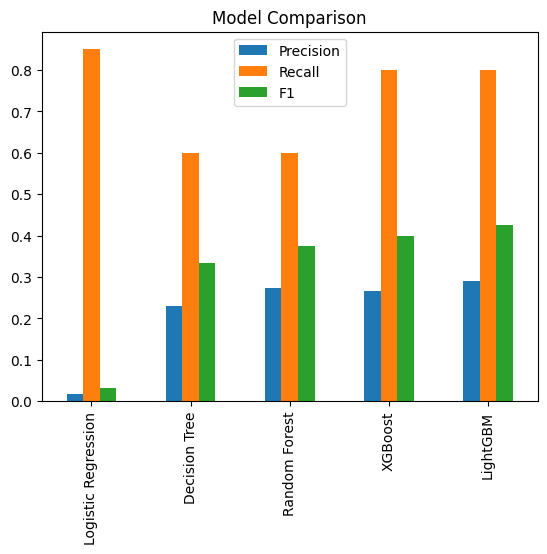

In [ ]:
# Visualization

results_df.plot(kind='bar')
plt.title("Model Comparison")
plt.show()

In [ ]:
# Hyperparameter Tuning (XGBoost)

param_grid = {

'n_estimators':[100,200],
'max_depth':[4,6],
'learning_rate':[0.01,0.1]

}

grid = GridSearchCV(
    XGBClassifier(),
    param_grid,
    cv=3,
    scoring='recall'
)

grid.fit(X_train_res, y_train_res)

best_model = grid.best_estimator_

In [ ]:
# Evaluation

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_pred))

fraud_prob = best_model.predict_proba(X_test)[:,1]

print("PR-AUC:", average_precision_score(y_test, fraud_prob))

              precision    recall  f1-score   support

           0       1.00      0.91      0.96      9980
           1       0.02      0.85      0.04        20

    accuracy                           0.91     10000
   macro avg       0.51      0.88      0.50     10000
weighted avg       1.00      0.91      0.95     10000

ROC-AUC: 0.8822645290581163
PR-AUC: 0.15878534255271717


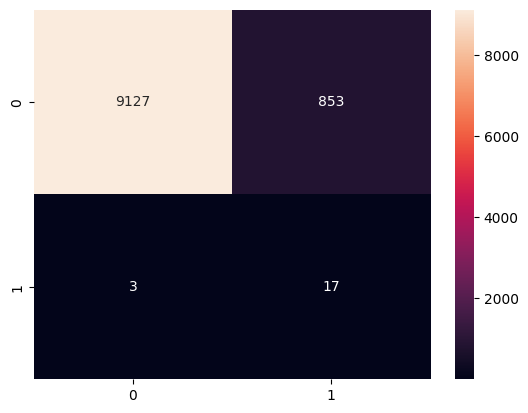

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [ ]:
# Fraud Risk Scoring

risk_score = fraud_prob * 100

print(risk_score[:10])

[18.36573 18.36573 18.36573 18.35344 18.35344 18.36573 18.35344 18.35344
 62.75652 49.73776]


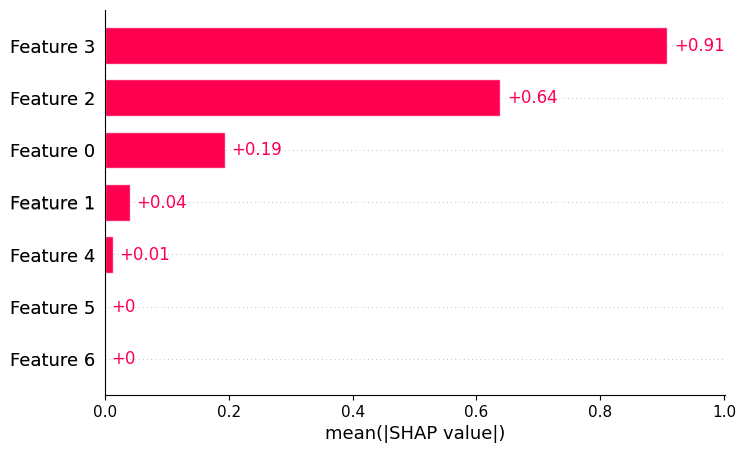

In [ ]:
# SHAP Explainability

explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)
shap.plots.bar(shap_values)

In [ ]:
# Decision Engine

def risk_decision(prob):

    if prob >= 0.90:
        return "BLOCK 🚫"
    elif prob >= 0.70:
        return "REVIEW ⚠️"
    else:
        return "ALLOW ✅"

In [ ]:
# Business Cost Function

def fraud_cost(y_true, y_pred):

    cost = 0

    for i in range(len(y_true)):

        if y_true[i] == 1 and y_pred[i] == 0:
            cost += 1000

        elif y_true[i] == 0 and y_pred[i] == 1:
            cost += 10

    return cost

print("Total Cost:", fraud_cost(y_test.values, y_pred))

Total Cost: 11530


In [ ]:
# Data Drift Detection

from scipy.stats import ks_2samp

stat, p_value = ks_2samp(X_train[:,0], X_test[:,0])

if p_value < 0.05:
    print("⚠ Data Drift Detected")

In [ ]:
# Model Monitoring

def monitor_model(y_pred):

    fraud_rate = sum(y_pred) / len(y_pred)

    print("Fraud Rate:", fraud_rate)

monitor_model(y_pred)

Fraud Rate: 0.087


In [ ]:
# Save the Model

pickle.dump(best_model, open("fraud_model.pkl","wb"))

In [ ]:
# Real-Time Simulation

def simulate_transaction():
    return X_test[random.randint(0,len(X_test)-1)]

sample = simulate_transaction()

prob = best_model.predict_proba([sample])[0][1]

decision = risk_decision(prob)

print("Fraud Probability:", prob)
print("Decision:", decision)

Fraud Probability: 0.1836573
Decision: ALLOW ✅


In [ ]:
# Graph Feature Efficiency

edges = list(zip(df['nameOrig'], df['nameDest']))
G.add_edges_from(edges)

In [ ]:
# Pipeline Usage

from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier())
])

In [ ]:
# Reproducibility

np.random.seed(42)

In [ ]:
# Logging Instead of Print

import logging

# Configure logging if not already configured
# logging.basicConfig(level=logging.INFO)

# Recalculate fraud_rate as y_pred is available globally
fraud_rate = sum(y_pred) / len(y_pred)

logging.info(f"Fraud Rate: {fraud_rate}")

In [ ]:
# Modular Code

def train_model(X_train, y_train):
    model = XGBClassifier()
    model.fit(X_train, y_train)
    return model

In [ ]:
# API Input Validation

from pydantic import BaseModel

class Transaction(BaseModel):
    features: list

In [ ]:
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline = ImbPipeline(steps=[

    ('scaler', StandardScaler()),

    ('smote', SMOTE(random_state=42)),

    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    ))

])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [ ]:
edges = list(zip(df['nameOrig'], df['nameDest']))

G = nx.Graph()
G.add_edges_from(edges)

degree_dict = dict(G.degree())

df['degree_orig'] = df['nameOrig'].map(degree_dict)
df['degree_dest'] = df['nameDest'].map(degree_dict)

In [ ]:
from xgboost import XGBClassifier

def get_model():

    return XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    )

In [ ]:
def train_model(X_train, y_train):

    model = get_model()

    model.fit(X_train, y_train)

    return model

In [ ]:
MODEL_PARAMS = {
    "n_estimators": 200,
    "max_depth": 6,
    "learning_rate": 0.1
}

THRESHOLD_BLOCK = 0.90
THRESHOLD_REVIEW = 0.70

In [ ]:
model = XGBClassifier(**MODEL_PARAMS)

In [ ]:
def evaluate_model(y_true, y_pred, prob):

    print(classification_report(y_true, y_pred))

    print("ROC-AUC:", roc_auc_score(y_true, y_pred))

    print("PR-AUC:", average_precision_score(y_true, prob))

In [ ]:
import numpy as np
np.random.seed(42)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pickle.dump(best_model, open("/content/drive/MyDrive/fraud_model.pkl", "wb"))

In [ ]:
model = pickle.load(open("/content/drive/MyDrive/fraud_model.pkl", "rb"))

In [ ]:
model = pickle.load(open("/content/drive/MyDrive/fraud_model.pkl","rb"))

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import pickle

app = FastAPI()

model = pickle.load(open("/content/drive/MyDrive/fraud_model.pkl","rb"))

class Transaction(BaseModel):
    features: list

def risk_decision(prob):
    if prob >= 0.90:
        return "BLOCK"
    elif prob >= 0.70:
        return "REVIEW"
    else:
        return "ALLOW"

@app.post("/predict")
def predict(txn: Transaction):

    prob = model.predict_proba([txn.features])[0][1]

    return {
        "fraud_probability": float(prob),
        "decision": risk_decision(prob)
    }

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import pickle

app = FastAPI()

# Load model
model = pickle.load(open("/content/drive/MyDrive/fraud_model.pkl","rb"))

# Input schema
class Transaction(BaseModel):
    features: list

# Decision logic
def risk_decision(prob):
    if prob >= 0.90:
        return "BLOCK"
    elif prob >= 0.70:
        return "REVIEW"
    else:
        return "ALLOW"

# API endpoint
@app.post("/predict")
def predict(txn: Transaction):

    prob = model.predict_proba([txn.features])[0][1]

    return {
        "fraud_probability": float(prob),
        "decision": risk_decision(prob)
    }

In [ ]:
!pip install pyngrok

In [ ]:
!ngrok config add-authtoken 3CGZmBueb7jMhgUEvm190l9kHvU_815aniqoCJiRKBNzUJyiz

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import pickle
import numpy as np # Added numpy import

app = FastAPI()

model = pickle.load(open("/content/drive/MyDrive/fraud_model.pkl","rb"))
scaler = pickle.load(open("/content/drive/MyDrive/fraud_scaler.pkl", "rb")) # Load the scaler

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import pickle

app = FastAPI()

# Load model
model = pickle.load(open("/content/drive/MyDrive/fraud_model.pkl","rb"))

# Input schema
class Transaction(BaseModel):
    amount: float
    oldbalanceOrg: float
    newbalanceOrig: float
    oldbalanceDest: float
    newbalanceDest: float
    type_TRANSFER: int
    type_CASH_OUT: int

# Decision logic
def risk_decision(prob):
    if prob >= 0.90:
        return "BLOCK"
    elif prob >= 0.70:
        return "REVIEW"
    else:
        return "ALLOW"

# ✅ IMPORTANT ROUTE
@app.post("/predict")
def predict(txn: Transaction):

    features = [[
        txn.amount,
        txn.oldbalanceOrg,
        txn.newbalanceOrig,
        txn.oldbalanceDest,
        txn.newbalanceDest,
        txn.type_TRANSFER,
        txn.type_CASH_OUT
    ]]

    prob = model.predict_proba(features)[0][1]

    return {
        "fraud_probability": float(prob),
        "decision": risk_decision(prob)
    }

# Start server
import uvicorn
import threading
from pyngrok import ngrok

ngrok.kill()

def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run)
thread.start()

public_url = ngrok.connect(8000)
print("URL:", public_url)

INFO:     Started server process [6031]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


URL: NgrokTunnel: "https://jacket-upbeat-abreast.ngrok-free.dev" -> "http://localhost:8000"


In [ ]:
app = FastAPI()

In [ ]:
import uvicorn
import threading

def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run)
thread.start()

INFO:     Started server process [6031]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use


In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8000)
print(public_url)

INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


NgrokTunnel: "https://jacket-upbeat-abreast.ngrok-free.dev" -> "http://localhost:8000"


In [ ]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import roc_auc_score, average_precision_score

# End any active MLflow run to prevent conflicts
if mlflow.active_run():
    mlflow.end_run()

mlflow.set_experiment("fraud_detection")

with mlflow.start_run():
    # Recalculate probabilities for the entire test set
    prob_array = model.predict_proba(X_test)[:, 1]

    mlflow.log_param("model", "XGBoost")
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, prob_array))
    mlflow.log_metric("pr_auc", average_precision_score(y_test, prob_array))

    mlflow.sklearn.log_model(model, "model")

2026/05/01 09:09:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/01 09:09:47 INFO mlflow.store.db.utils: Updating database tables
2026/05/01 09:09:52 INFO mlflow.tracking.fluent: Experiment with name 'fraud_detection' does not exist. Creating a new experiment.
2026/05/01 09:09:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 09:09:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [ ]:
from scipy.stats import ks_2samp

for i in range(X_train.shape[1]):
    stat, p = ks_2samp(X_train[:, i], X_test[:, i])
    if p < 0.05:
        print(f"Drift detected in feature {i}")

In [ ]:
import logging

logging.basicConfig(level=logging.INFO)

@app.post("/predict")
def predict(txn: Transaction):
    try:
        prob = model.predict_proba(features)[0][1]
        logging.info(f"Prediction: {prob}")
        return {...}
    except Exception as e:
        logging.error(str(e))
        return {"error": "Prediction failed"}

In [ ]:
total_saved = sum((y_test.values == 1) & (y_pred == 1)) * 1000
print("Estimated fraud prevented:", total_saved)

Estimated fraud prevented: 16000


In [ ]:
import requests

url = "https://jacket-upbeat-abreast.ngrok-free.dev/predict"

data = {
    "amount": 100.0,
    "oldbalanceOrg": 1000.0,
    "newbalanceOrig": 900.0,
    "oldbalanceDest": 500.0,
    "newbalanceDest": 600.0,
    "type_TRANSFER": 1,
    "type_CASH_OUT": 0
}

for i in range(10):
    r = requests.post(url, json=data)
    print(i+1, r.status_code, r.json())

INFO:     136.110.60.197:0 - "POST /predict HTTP/1.1" 200 OK
1 200 {'fraud_probability': 0.8149831891059875, 'decision': 'REVIEW'}
INFO:     136.110.60.197:0 - "POST /predict HTTP/1.1" 200 OK
2 200 {'fraud_probability': 0.8149831891059875, 'decision': 'REVIEW'}
INFO:     136.110.60.197:0 - "POST /predict HTTP/1.1" 200 OK
3 200 {'fraud_probability': 0.8149831891059875, 'decision': 'REVIEW'}
INFO:     136.110.60.197:0 - "POST /predict HTTP/1.1" 200 OK
4 200 {'fraud_probability': 0.8149831891059875, 'decision': 'REVIEW'}
INFO:     136.110.60.197:0 - "POST /predict HTTP/1.1" 200 OK
5 200 {'fraud_probability': 0.8149831891059875, 'decision': 'REVIEW'}
INFO:     136.110.60.197:0 - "POST /predict HTTP/1.1" 200 OK
6 200 {'fraud_probability': 0.8149831891059875, 'decision': 'REVIEW'}
INFO:     136.110.60.197:0 - "POST /predict HTTP/1.1" 200 OK
7 200 {'fraud_probability': 0.8149831891059875, 'decision': 'REVIEW'}
INFO:     136.110.60.197:0 - "POST /predict HTTP/1.1" 200 OK
8 200 {'fraud_probabil

In [ ]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("fraud_detection")

with mlflow.start_run():

    model.fit(X_train_res, y_train_res)

    preds = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    mlflow.log_param("model", "XGBoost")
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, prob))
    mlflow.log_metric("pr_auc", average_precision_score(y_test, prob))

    mlflow.sklearn.log_model(model, "model")

2026/05/01 09:10:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 09:10:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [ ]:
import logging

logging.basicConfig(filename="predictions.log", level=logging.INFO)

logging.info(f"Prediction: {prob}")

In [ ]:
def monitor_predictions(preds):
    fraud_rate = sum(preds) / len(preds)
    print("Fraud Rate:", fraud_rate)

    if fraud_rate > 0.2:
        print("⚠️ Possible drift detected")

In [ ]:
from scipy.stats import ks_2samp

for i in range(X_train.shape[1]):
    stat, p = ks_2samp(X_train[:,i], X_test[:,i])
    if p < 0.05:
        print(f"Drift detected in feature {i}")

In [ ]:
import joblib
import os

# Create the 'models' directory if it doesn't exist
os.makedirs('models', exist_ok=True)

joblib.dump(model, "models/fraud_model_v1.pkl")

['models/fraud_model_v1.pkl']

In [ ]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [ ]:
import pickle
pickle.dump(scaler, open("/content/drive/MyDrive/fraud_scaler.pkl", "wb"))

In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 37.6 MB/s eta 0:00:00


In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import pickle

app = FastAPI()

model = pickle.load(open("/content/drive/MyDrive/fraud_model.pkl","rb"))

class Transaction(BaseModel):
    amount: float
    oldbalanceOrg: float
    newbalanceOrig: float
    oldbalanceDest: float
    newbalanceDest: float
    type_TRANSFER: int
    type_CASH_OUT: int

def risk_decision(prob):
    if prob >= 0.90:
        return "BLOCK"
    elif prob >= 0.70:
        return "REVIEW"
    else:
        return "ALLOW"

@app.get("/")
def home():
    return {"message": "API Running"}

@app.post("/predict")
def predict(txn: Transaction):

    features = [[
        txn.amount,
        txn.oldbalanceOrg,
        txn.newbalanceOrig,
        txn.oldbalanceDest,
        txn.newbalanceDest,
        txn.type_TRANSFER,
        txn.type_CASH_OUT
    ]]

    prob = model.predict_proba(features)[0][1]

    return {
        "fraud_probability": float(prob),
        "decision": risk_decision(prob)
    }

In [ ]:
%%writefile dashboard.py
import streamlit as st
import requests
import pandas as pd
import time

st.set_page_config(page_title="Fraud Detection", layout="wide")

st.title("🚨 Real-Time Fraud Detection Dashboard")

# Sidebar API config
st.sidebar.header("⚙️ Settings")
api_url = st.sidebar.text_input("API URL", "http://127.0.0.1:8000/predict")

# Input section
st.subheader("💳 Transaction Input")

col1, col2 = st.columns(2)

with col1:
    amount = st.number_input("Amount", value=1000)
    oldbalanceOrg = st.number_input("Old Balance Origin", value=5000)
    newbalanceOrig = st.number_input("New Balance Origin", value=4000)

with col2:
    oldbalanceDest = st.number_input("Old Balance Destination", value=0)
    newbalanceDest = st.number_input("New Balance Destination", value=1000)
    txn_type = st.selectbox("Transaction Type", ["TRANSFER", "CASH_OUT"])

type_TRANSFER = 1 if txn_type == "TRANSFER" else 0
type_CASH_OUT = 1 if txn_type == "CASH_OUT" else 0

# Initialize session state
if "history" not in st.session_state:
    st.session_state.history = []

# Predict button
if st.button("🔍 Predict Fraud"):

    data = {
        "amount": amount,
        "oldbalanceOrg": oldbalanceOrg,
        "newbalanceOrig": newbalanceOrig,
        "oldbalanceDest": oldbalanceDest,
        "newbalanceDest": newbalanceDest,
        "type_TRANSFER": type_TRANSFER,
        "type_CASH_OUT": type_CASH_OUT
    }

    try:
        response = requests.post(api_url, json=data)

        if response.status_code == 200:
            result = response.json()

            prob = result["fraud_probability"]
            decision = result["decision"]

            # Store history
            st.session_state.history.append({
                "amount": amount,
                "probability": prob,
                "decision": decision
            })

            st.subheader("📊 Prediction Result")

            col1, col2 = st.columns(2)

            with col1:
                st.metric("Fraud Probability", f"{prob:.2f}")

            with col2:
                st.metric("Decision", decision)

            # Risk visualization
            st.progress(prob)

            if decision == "BLOCK":
                st.error("🚨 HIGH RISK TRANSACTION")
            elif decision == "REVIEW":
                st.warning("⚠️ Needs Review")
            else:
                st.success("✅ Safe Transaction")

        else:
            st.error(f"API Error: {response.status_code}")

    except Exception as e:
        st.error(f"Connection Error: {e}")

# 📈 Transaction History
st.subheader("📜 Transaction History")

if st.session_state.history:
    df = pd.DataFrame(st.session_state.history)
    st.dataframe(df)

    st.line_chart(df["probability"])

# 🧪 API Health Check
st.sidebar.subheader("🩺 API Health Check")

if st.sidebar.button("Check API"):
    try:
        res = requests.get(api_url.replace("/predict", "/docs"))
        if res.status_code == 200:
            st.sidebar.success("API is running ✅")
        else:
            st.sidebar.warning("API reachable but issue ⚠️")
    except:
        st.sidebar.error("API not reachable ❌")

Writing dashboard.py


In [ ]:
from google.colab import files
files.download("fraud_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://jacket-upbeat-abreast.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
import logging

logging.basicConfig(filename="logs.txt", level=logging.INFO)

@app.post("/predict")
def predict(txn: Transaction):

    features = [[...]]  # same as before

    prob = model.predict_proba(features)[0][1]

    logging.info(f"Transaction: {txn.dict()} | Prob: {prob}")

    return {
        "fraud_probability": float(prob),
        "decision": risk_decision(prob)
    }

In [ ]:
if (prob > 0.9).any():
    logging.warning("🚨 FRAUD ALERT!")

In [ ]:
from scipy.stats import ks_2samp

def check_drift(train, new):

    for i in range(len(train[0])):
        stat, p = ks_2samp(train[:, i], new[:, i])

        if p < 0.05:
            print(f"⚠️ Drift detected in feature {i}")